<cell_type>markdown</cell_type># Part B — Notebook 2: Log-Level Classification
#
# **Research**: Beyond Gut Feel — AI vs Developer Intuition in Observability Decisions
#
# **Goal**: Train classifiers to predict log level from code context,
# compare against keyword heuristic baseline, evaluate cross-project generalization.
#
# **Figures produced**:
# - `fig07_model_comparison.png` — Baseline vs ML model F1 scores
# - `fig08_confusion_matrix.png` — XGBoost confusion matrix (counts + %)
# - `fig10_cross_project.png` — Per-repo cross-project F1 comparison
# - `fig11_feature_importance.png` — Top 25 features by importance
#
# **Input**: `data/log_level_dataset.csv` (from notebook 01)
#
# **Run time**: ~3 minutes
#
# ---

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

# === Google Drive mount (persists data across notebooks) ===
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/beyond-gut-feel'
except ImportError:
    BASE_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), '..')

FIGURE_DIR = os.path.join(BASE_DIR, 'figures')
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(FIGURE_DIR, exist_ok=True)

# Publication style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'figure.figsize': (10, 5),
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

np.random.seed(42)

print(f'Figures → {os.path.abspath(FIGURE_DIR)}')
print(f'Data   → {os.path.abspath(DATA_DIR)}')
print('Libraries loaded!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Figures → /content/drive/MyDrive/beyond-gut-feel/figures
Data   → /content/drive/MyDrive/beyond-gut-feel/data
Libraries loaded!


In [7]:
# Load the mined dataset from notebook 01
df = pd.read_csv(os.path.join(DATA_DIR, 'log_level_dataset.csv'))
print(f'Loaded {len(df):,} log statements from {df["repo"].nunique()} repos')
print(f'Class distribution:')
for level in ['DEBUG', 'INFO', 'WARN', 'ERROR']:
    count = len(df[df['log_level'] == level])
    print(f'  {level:6s}: {count:>5,} ({count/len(df)*100:.1f}%)')

Loaded 15,702 log statements from 15 repos
Class distribution:
  DEBUG : 2,155 (13.7%)
  INFO  : 7,047 (44.9%)
  WARN  : 2,096 (13.3%)
  ERROR : 4,404 (28.0%)


## 1. Feature Engineering

Rebuild features from the saved dataset (same as Step 1 but self-contained).

In [8]:
# --- Text features via TF-IDF ---
context_tfidf = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    stop_words='english', min_df=5, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
message_tfidf = TfidfVectorizer(
    max_features=200, ngram_range=(1, 2),
    min_df=3, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)

X_context = context_tfidf.fit_transform(df['full_context'].fillna(''))
X_message = message_tfidf.fit_transform(df['log_message'].fillna(''))

# --- Structural features ---
structural_cols = ['in_catch', 'in_conditional', 'in_try',
                   'has_return', 'has_throw', 'var_count',
                   'msg_length', 'line_length']
X_structural = df[structural_cols].astype(float).values

# --- File type (one-hot) ---
X_filetype = pd.get_dummies(df['file_type'], prefix='ft').values
filetype_cols = list(pd.get_dummies(df['file_type'], prefix='ft').columns)

# --- Combine ---
X_all = sp.hstack([X_context, X_message, sp.csr_matrix(X_structural), sp.csr_matrix(X_filetype)])

# --- Labels ---
le = LabelEncoder()
y = le.fit_transform(df['log_level'])
class_names = list(le.classes_)

print(f'Feature matrix: {X_all.shape}')
print(f'Classes: {class_names}')

Feature matrix: (15702, 715)
Classes: ['DEBUG', 'ERROR', 'INFO', 'WARN']


## 2. Baseline 1 — Random Guess

The simplest possible baseline: predict each class proportional to its frequency.
Any useful model must beat this.

In [9]:
# Random baseline — predict proportional to class frequency
np.random.seed(42)
class_probs = df['log_level'].value_counts(normalize=True)
random_preds = np.random.choice(
    le.transform(class_probs.index),
    size=len(y),
    p=class_probs.values
)

print('BASELINE 1: Random Guess (proportional to class frequency)')
print(f'  Accuracy:  {accuracy_score(y, random_preds):.4f}')
print(f'  Macro F1:  {f1_score(y, random_preds, average="macro"):.4f}')
print(f'  Weighted F1: {f1_score(y, random_preds, average="weighted"):.4f}')
print()
print(classification_report(y, random_preds, target_names=class_names))

BASELINE 1: Random Guess (proportional to class frequency)
  Accuracy:  0.3187
  Macro F1:  0.2513
  Weighted F1: 0.3180

              precision    recall  f1-score   support

       DEBUG       0.13      0.13      0.13      2155
       ERROR       0.28      0.28      0.28      4404
        INFO       0.45      0.45      0.45      7047
        WARN       0.14      0.14      0.14      2096

    accuracy                           0.32     15702
   macro avg       0.25      0.25      0.25     15702
weighted avg       0.32      0.32      0.32     15702



## 3. Baseline 2 — Keyword Heuristic

This mimics what a developer does mentally:
- See `catch` or `error` or `fail` → predict ERROR
- See `warn` or `deprecated` → predict WARN
- See `debug` or `trace` or `verbose` → predict DEBUG
- Everything else → predict INFO

This is the formalized version of gut feel.

In [10]:
def keyword_heuristic(row):
    """
    Predict log level based on keyword rules.
    This is what a developer's gut feel looks like as code.
    """
    context = str(row['full_context']).lower()
    message = str(row['log_message']).lower()
    combined = context + ' ' + message

    # Rule 1: catch block + error keywords → ERROR
    if row.get('in_catch', False):
        return 'ERROR'

    # Rule 2: throw nearby → ERROR
    if row.get('has_throw', False):
        return 'ERROR'

    # Rule 3: error-related keywords in message
    error_keywords = ['error', 'fail', 'exception', 'crash', 'fatal',
                      'unable to', 'cannot', 'could not', 'unexpected']
    if any(kw in message for kw in error_keywords):
        return 'ERROR'

    # Rule 4: warning keywords
    warn_keywords = ['warn', 'deprecat', 'fallback', 'retry',
                     'timeout', 'slow', 'missing', 'not found',
                     'skipping', 'ignoring']
    if any(kw in message for kw in warn_keywords):
        return 'WARN'

    # Rule 5: debug keywords
    debug_keywords = ['debug', 'trace', 'verbose', 'entering',
                      'leaving', 'params:', 'args:', 'query:']
    if any(kw in message for kw in debug_keywords):
        return 'DEBUG'

    # Default: INFO
    return 'INFO'

# Apply heuristic
heuristic_preds = df.apply(keyword_heuristic, axis=1)
heuristic_encoded = le.transform(heuristic_preds)

print('BASELINE 2: Keyword Heuristic ("Formalized Gut Feel")')
print(f'  Accuracy:  {accuracy_score(y, heuristic_encoded):.4f}')
print(f'  Macro F1:  {f1_score(y, heuristic_encoded, average="macro"):.4f}')
print(f'  Weighted F1: {f1_score(y, heuristic_encoded, average="weighted"):.4f}')
print()
print(classification_report(y, heuristic_encoded, target_names=class_names))

BASELINE 2: Keyword Heuristic ("Formalized Gut Feel")
  Accuracy:  0.6067
  Macro F1:  0.3769
  Weighted F1: 0.5268

              precision    recall  f1-score   support

       DEBUG       0.26      0.00      0.01      2155
       ERROR       0.60      0.71      0.65      4404
        INFO       0.62      0.88      0.73      7047
        WARN       0.38      0.07      0.12      2096

    accuracy                           0.61     15702
   macro avg       0.47      0.42      0.38     15702
weighted avg       0.53      0.61      0.53     15702



## 4. ML Models — Stratified Cross-Validation

### Why cross-validation instead of a single train/test split?

With a single split, we might get lucky or unlucky. Cross-validation trains
and tests 5 times on different folds, giving us a reliable average score.

**Stratified** means each fold has the same class proportions as the full dataset
(important because DEBUG and WARN are underrepresented).

We'll train 3 models:
1. **Logistic Regression** — simple linear model (fast, interpretable)
2. **Random Forest** — ensemble of decision trees (handles non-linear patterns)
3. **XGBoost** — gradient-boosted trees (usually best performance)

In [11]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=8,
        learning_rate=0.1, random_state=42,
        eval_metric='mlogloss', n_jobs=-1
    ),
}

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {name: {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}
              for name in models}

print('Running 5-fold cross-validation...\n')

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y)):
    X_train_fold = X_all[train_idx]
    X_test_fold = X_all[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]

    for name, model in models.items():
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_test_fold)

        cv_results[name]['accuracy'].append(accuracy_score(y_test_fold, preds))
        cv_results[name]['macro_f1'].append(f1_score(y_test_fold, preds, average='macro'))
        cv_results[name]['weighted_f1'].append(f1_score(y_test_fold, preds, average='weighted'))

    print(f'  Fold {fold+1}/5 complete')

print('\nDone!')

Running 5-fold cross-validation...

  Fold 1/5 complete
  Fold 2/5 complete
  Fold 3/5 complete
  Fold 4/5 complete
  Fold 5/5 complete

Done!


In [12]:
# Display cross-validation results
print('=' * 70)
print('CROSS-VALIDATION RESULTS (5-fold, mean +/- std)')
print('=' * 70)

comparison_rows = []

# Add baselines
comparison_rows.append({
    'Model': 'Random Guess',
    'Accuracy': f'{accuracy_score(y, random_preds):.4f}',
    'Macro F1': f'{f1_score(y, random_preds, average="macro"):.4f}',
    'Weighted F1': f'{f1_score(y, random_preds, average="weighted"):.4f}',
    'Type': 'Baseline'
})
comparison_rows.append({
    'Model': 'Keyword Heuristic',
    'Accuracy': f'{accuracy_score(y, heuristic_encoded):.4f}',
    'Macro F1': f'{f1_score(y, heuristic_encoded, average="macro"):.4f}',
    'Weighted F1': f'{f1_score(y, heuristic_encoded, average="weighted"):.4f}',
    'Type': 'Gut Feel'
})

# Add ML models
for name, metrics in cv_results.items():
    acc = np.mean(metrics['accuracy'])
    acc_std = np.std(metrics['accuracy'])
    mf1 = np.mean(metrics['macro_f1'])
    mf1_std = np.std(metrics['macro_f1'])
    wf1 = np.mean(metrics['weighted_f1'])
    wf1_std = np.std(metrics['weighted_f1'])

    comparison_rows.append({
        'Model': name,
        'Accuracy': f'{acc:.4f} +/- {acc_std:.4f}',
        'Macro F1': f'{mf1:.4f} +/- {mf1_std:.4f}',
        'Weighted F1': f'{wf1:.4f} +/- {wf1_std:.4f}',
        'Type': 'ML'
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

CROSS-VALIDATION RESULTS (5-fold, mean +/- std)
              Model          Accuracy          Macro F1       Weighted F1     Type
       Random Guess            0.3187            0.2513            0.3180 Baseline
  Keyword Heuristic            0.6067            0.3769            0.5268 Gut Feel
Logistic Regression 0.6462 +/- 0.0178 0.5907 +/- 0.0281 0.6536 +/- 0.0172       ML
      Random Forest 0.9583 +/- 0.0040 0.9532 +/- 0.0047 0.9584 +/- 0.0040       ML
            XGBoost 0.9671 +/- 0.0026 0.9614 +/- 0.0028 0.9672 +/- 0.0025       ML


## 5. Full Training + Confusion Matrix

Train the best model on 80% of data, test on 20%.
The confusion matrix shows exactly which levels get confused.

In [13]:
from sklearn.model_selection import train_test_split

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# Train best model (XGBoost — usually wins)
best_model = XGBClassifier(
    n_estimators=300, max_depth=10,
    learning_rate=0.1, random_state=42,
    eval_metric='mlogloss', n_jobs=-1
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print('BEST MODEL: XGBoost — Full Train/Test Results')
print('=' * 60)
print(f'Accuracy:    {accuracy_score(y_test, y_pred):.4f}')
print(f'Macro F1:    {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Weighted F1: {f1_score(y_test, y_pred, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=class_names))

BEST MODEL: XGBoost — Full Train/Test Results
Accuracy:    0.9656
Macro F1:    0.9592
Weighted F1: 0.9657

              precision    recall  f1-score   support

       DEBUG       0.93      0.96      0.95       431
       ERROR       0.97      0.95      0.96       881
        INFO       0.98      0.98      0.98      1410
        WARN       0.93      0.96      0.95       419

    accuracy                           0.97      3141
   macro avg       0.96      0.96      0.96      3141
weighted avg       0.97      0.97      0.97      3141



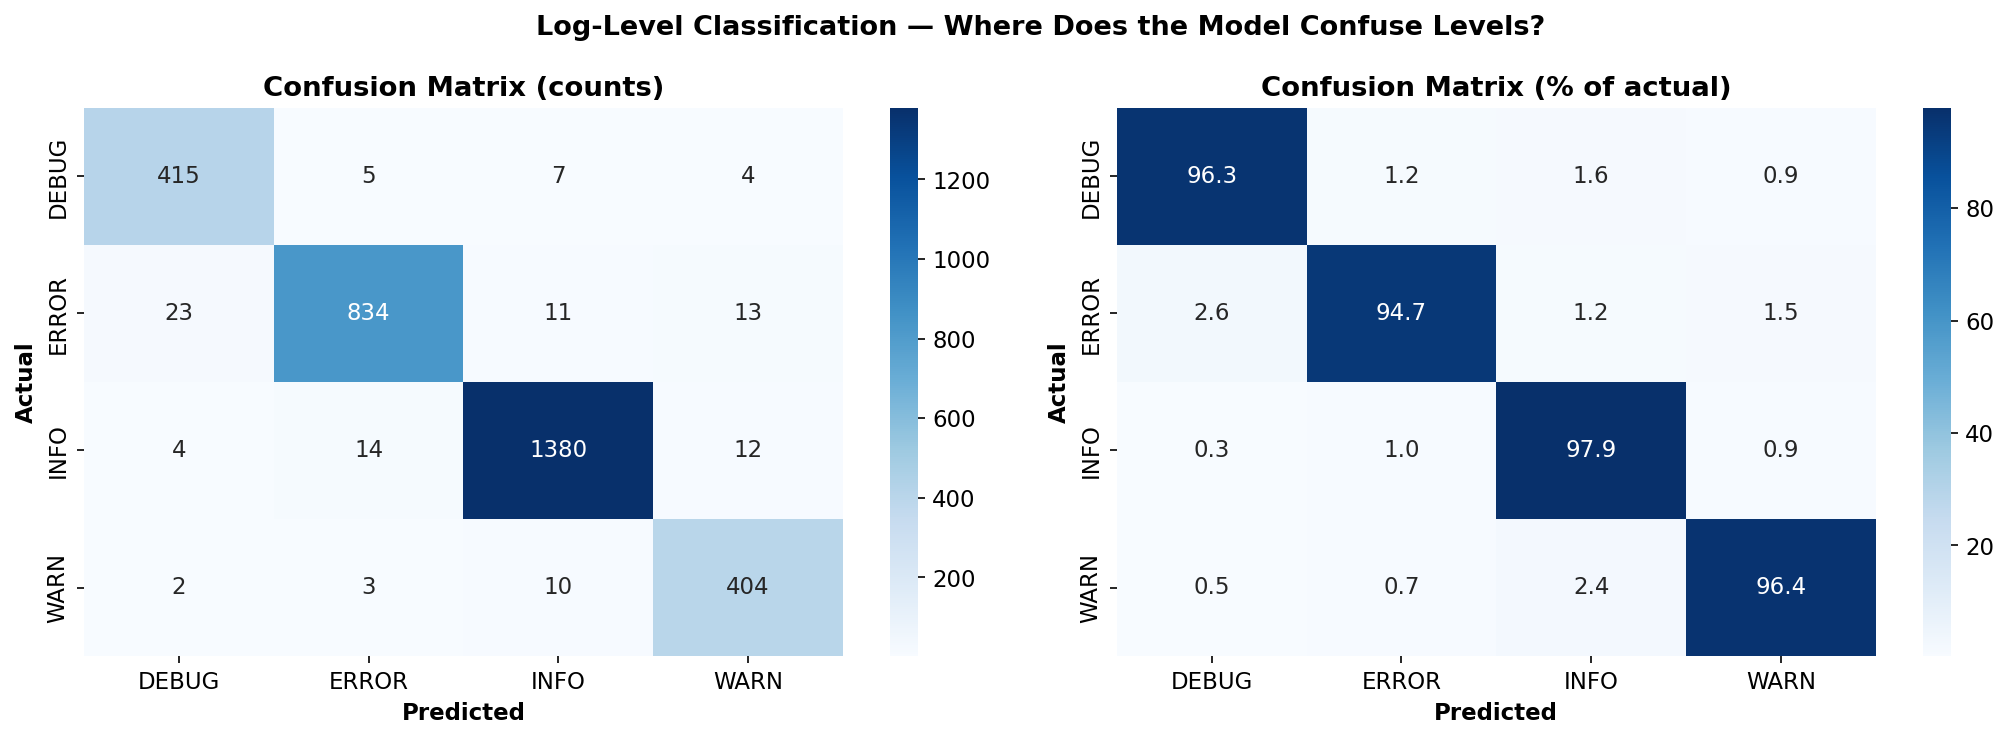


Key patterns to look for:
- High diagonal = correct predictions
- Off-diagonal = confusions
- DEBUG <-> INFO confusion = expected (thin boundary)
- WARN <-> ERROR confusion = interesting (are developers inconsistent?)


In [14]:
# Confusion Matrix — publication quality
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_xlabel('Predicted', fontweight='bold')
ax1.set_ylabel('Actual', fontweight='bold')
ax1.set_title('Confusion Matrix (counts)', fontweight='bold')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_xlabel('Predicted', fontweight='bold')
ax2.set_ylabel('Actual', fontweight='bold')
ax2.set_title('Confusion Matrix (% of actual)', fontweight='bold')

plt.suptitle('Log-Level Classification — Where Does the Model Confuse Levels?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig08_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print('\nKey patterns to look for:')
print('- High diagonal = correct predictions')
print('- Off-diagonal = confusions')
print('- DEBUG <-> INFO confusion = expected (thin boundary)')
print('- WARN <-> ERROR confusion = interesting (are developers inconsistent?)')

## 6. Cross-Project Evaluation

**The critical test**: Can the model predict log levels for code it has NEVER seen
from repos it was NEVER trained on?

If yes → log-level conventions are generalizable, not repo-specific.
If no → each repo has its own conventions (also a finding).

We train on 12 repos and test on 3 held-out repos.

In [15]:
# Cross-project evaluation
# Hold out 3 diverse repos for testing
test_repos = ['strapi', 'immich', 'calcom']
train_repos = [r for r in df['repo'].unique() if r not in test_repos]

print(f'Train repos ({len(train_repos)}): {train_repos}')
print(f'Test repos ({len(test_repos)}):  {test_repos}')

train_mask = df['repo'].isin(train_repos)
test_mask = df['repo'].isin(test_repos)

print(f'\nTrain set: {train_mask.sum():,} statements')
print(f'Test set:  {test_mask.sum():,} statements')

# Rebuild features for train/test split
# IMPORTANT: fit TF-IDF only on training data, transform test data
ctx_tfidf_cp = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    stop_words='english', min_df=5, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
msg_tfidf_cp = TfidfVectorizer(
    max_features=200, ngram_range=(1, 2),
    min_df=3, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)

# Fit on train, transform both
X_ctx_train = ctx_tfidf_cp.fit_transform(df.loc[train_mask, 'full_context'].fillna(''))
X_ctx_test = ctx_tfidf_cp.transform(df.loc[test_mask, 'full_context'].fillna(''))

X_msg_train = msg_tfidf_cp.fit_transform(df.loc[train_mask, 'log_message'].fillna(''))
X_msg_test = msg_tfidf_cp.transform(df.loc[test_mask, 'log_message'].fillna(''))

X_struct_train = df.loc[train_mask, structural_cols].astype(float).values
X_struct_test = df.loc[test_mask, structural_cols].astype(float).values

# File type — handle unseen categories
ft_dummies = pd.get_dummies(df['file_type'], prefix='ft')
X_ft_train = ft_dummies.loc[train_mask].values
X_ft_test = ft_dummies.loc[test_mask].values

X_cp_train = sp.hstack([X_ctx_train, X_msg_train,
                         sp.csr_matrix(X_struct_train),
                         sp.csr_matrix(X_ft_train)])
X_cp_test = sp.hstack([X_ctx_test, X_msg_test,
                        sp.csr_matrix(X_struct_test),
                        sp.csr_matrix(X_ft_test)])

y_cp_train = le.transform(df.loc[train_mask, 'log_level'])
y_cp_test = le.transform(df.loc[test_mask, 'log_level'])

print(f'\nFeature matrices: train {X_cp_train.shape}, test {X_cp_test.shape}')

Train repos (12): ['nestjs', 'express', 'fastify', 'typeorm', 'prisma', 'medusa', 'n8n', 'supabase', 'payload', 'directus', 'outline', 'nocodb']
Test repos (3):  ['strapi', 'immich', 'calcom']

Train set: 12,247 statements
Test set:  3,455 statements

Feature matrices: train (12247, 715), test (3455, 715)


In [16]:
# Train and evaluate on unseen repos
cp_model = XGBClassifier(
    n_estimators=300, max_depth=10,
    learning_rate=0.1, random_state=42,
    eval_metric='mlogloss', n_jobs=-1
)
cp_model.fit(X_cp_train, y_cp_train)
cp_preds = cp_model.predict(X_cp_test)

# Also run keyword heuristic on test repos for comparison
heuristic_cp = df.loc[test_mask].apply(keyword_heuristic, axis=1)
heuristic_cp_encoded = le.transform(heuristic_cp)

print('=' * 70)
print('CROSS-PROJECT EVALUATION')
print(f'Trained on: {len(train_repos)} repos | Tested on: {test_repos}')
print('=' * 70)

print(f'\nKeyword Heuristic (gut feel):')
print(f'  Accuracy:  {accuracy_score(y_cp_test, heuristic_cp_encoded):.4f}')
print(f'  Macro F1:  {f1_score(y_cp_test, heuristic_cp_encoded, average="macro"):.4f}')

print(f'\nXGBoost (cross-project):')
print(f'  Accuracy:  {accuracy_score(y_cp_test, cp_preds):.4f}')
print(f'  Macro F1:  {f1_score(y_cp_test, cp_preds, average="macro"):.4f}')

improvement = (f1_score(y_cp_test, cp_preds, average='macro') -
               f1_score(y_cp_test, heuristic_cp_encoded, average='macro'))
print(f'\nML improvement over gut feel: {improvement:+.4f} macro F1')

print(f'\nPer-repo breakdown:')
for repo in test_repos:
    repo_mask = df.loc[test_mask, 'repo'] == repo
    repo_y = y_cp_test[repo_mask.values]
    repo_pred = cp_preds[repo_mask.values]
    repo_heur = heuristic_cp_encoded[repo_mask.values]
    print(f'  {repo:12s}: XGB F1={f1_score(repo_y, repo_pred, average="macro"):.4f} | '
          f'Heuristic F1={f1_score(repo_y, repo_heur, average="macro"):.4f} | '
          f'n={len(repo_y)}')

print('\n')
print(classification_report(y_cp_test, cp_preds, target_names=class_names))

CROSS-PROJECT EVALUATION
Trained on: 12 repos | Tested on: ['strapi', 'immich', 'calcom']

Keyword Heuristic (gut feel):
  Accuracy:  0.5702
  Macro F1:  0.3815

XGBoost (cross-project):
  Accuracy:  0.9265
  Macro F1:  0.9227

ML improvement over gut feel: +0.5411 macro F1

Per-repo breakdown:
  strapi      : XGB F1=0.8979 | Heuristic F1=0.3719 | n=1063
  immich      : XGB F1=0.9130 | Heuristic F1=0.3739 | n=570
  calcom      : XGB F1=0.9339 | Heuristic F1=0.3789 | n=1822


              precision    recall  f1-score   support

       DEBUG       0.88      0.88      0.88       621
       ERROR       0.94      0.94      0.94      1198
        INFO       0.94      0.93      0.93      1219
        WARN       0.92      0.96      0.94       417

    accuracy                           0.93      3455
   macro avg       0.92      0.93      0.92      3455
weighted avg       0.93      0.93      0.93      3455



## 7. Feature Importance — What Code Patterns Predict Log Level?

This answers: what does the model look at to decide the log level?
Connects back to Part A — which signals matter.

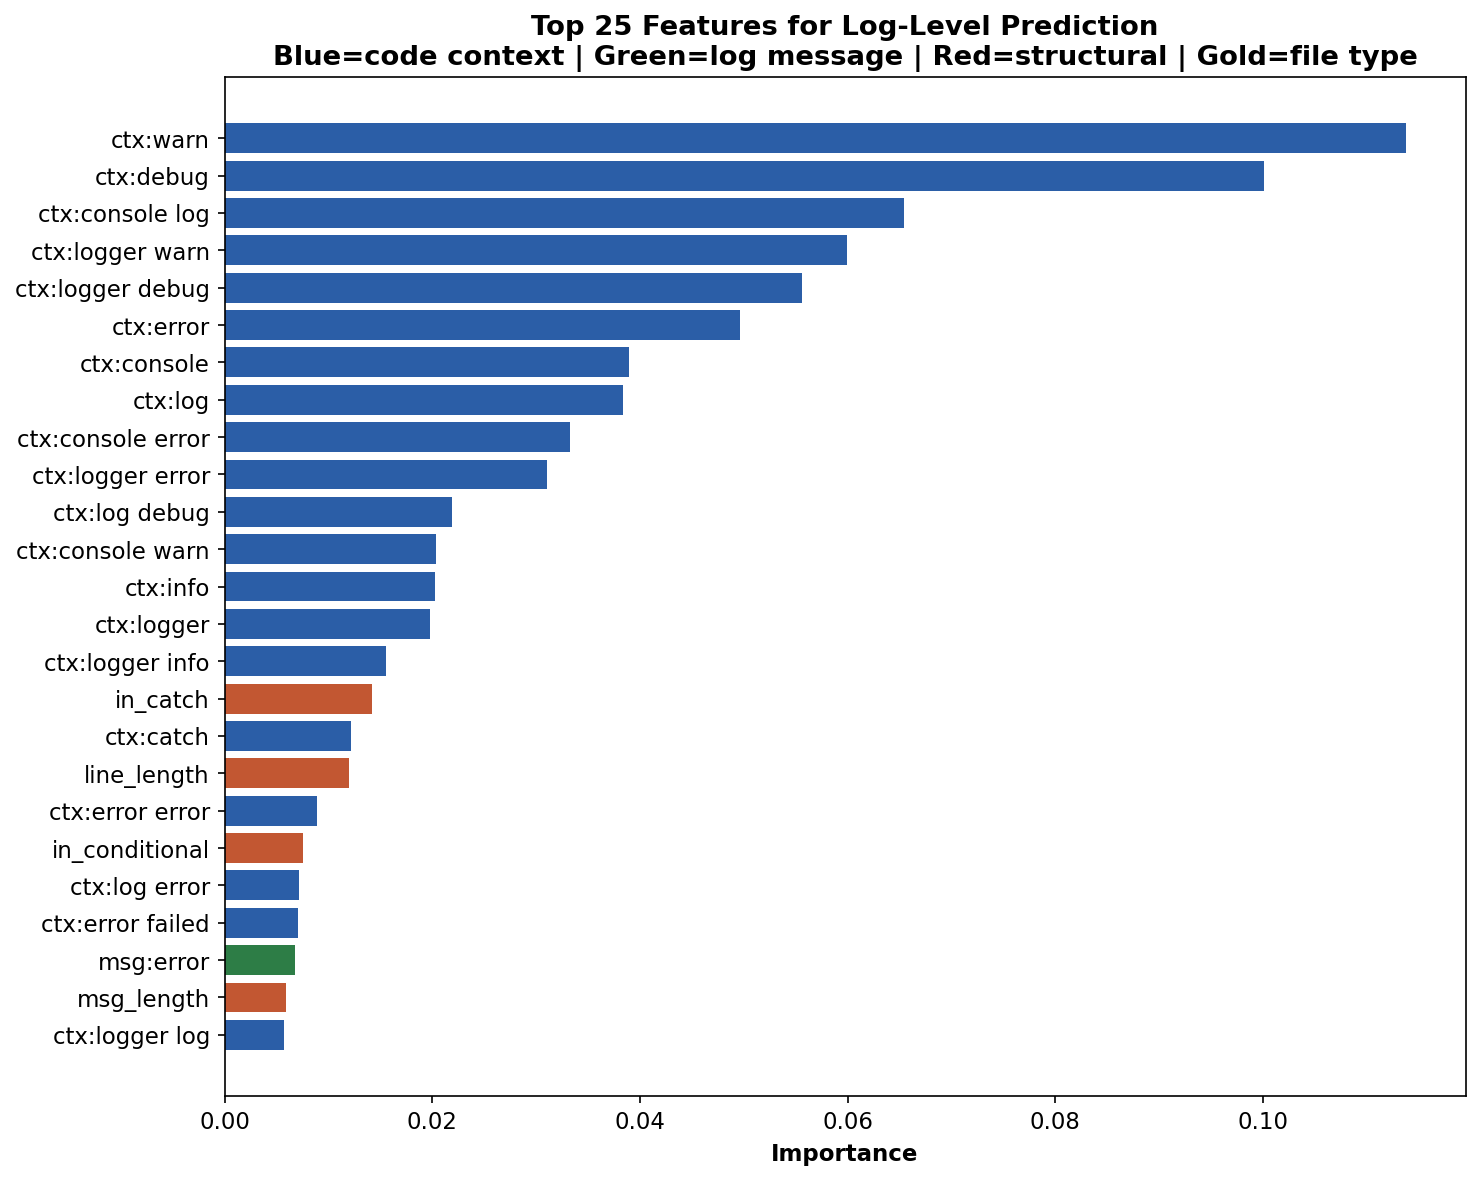


Top 5 structural features:
  in_catch             0.0142
  line_length          0.0120
  in_conditional       0.0076
  msg_length           0.0060
  var_count            0.0030

Top 5 code context features:
  ctx:warn             0.1138
  ctx:debug            0.1001
  ctx:console log      0.0655
  ctx:logger warn      0.0600
  ctx:logger debug     0.0556

Top 5 log message features:
  msg:error            0.0067
  msg:failed           0.0056
  msg:failed to        0.0036
  msg:required         0.0034
  msg:to               0.0026


In [17]:
# Train Random Forest on full data for interpretable feature importance
rf_full = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_full.fit(X_all, y)

# Get feature names
context_names = [f'ctx:{w}' for w in context_tfidf.get_feature_names_out()]
message_names = [f'msg:{w}' for w in message_tfidf.get_feature_names_out()]
all_feature_names = context_names + message_names + structural_cols + filetype_cols

# Sort by importance
importances = rf_full.feature_importances_
imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 25 features
top_n = 25
fig, ax = plt.subplots(figsize=(10, 8))
top = imp_df.head(top_n).sort_values('Importance', ascending=True)

# Color by feature type
def get_color(name):
    if name.startswith('ctx:'):
        return '#2B5EA7'
    elif name.startswith('msg:'):
        return '#2D7D46'
    elif name.startswith('ft_'):
        return '#B8860B'
    else:
        return '#C25732'

colors = [get_color(n) for n in top['Feature']]
ax.barh(top['Feature'], top['Importance'], color=colors)
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title(f'Top {top_n} Features for Log-Level Prediction\n'
             f'Blue=code context | Green=log message | Red=structural | Gold=file type',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig11_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print top features by category
print('\nTop 5 structural features:')
struct_imp = imp_df[~imp_df['Feature'].str.startswith(('ctx:', 'msg:', 'ft_'))]
for _, row in struct_imp.head().iterrows():
    print(f'  {row["Feature"]:20s} {row["Importance"]:.4f}')

print('\nTop 5 code context features:')
ctx_imp = imp_df[imp_df['Feature'].str.startswith('ctx:')]
for _, row in ctx_imp.head().iterrows():
    print(f'  {row["Feature"]:20s} {row["Importance"]:.4f}')

print('\nTop 5 log message features:')
msg_imp = imp_df[imp_df['Feature'].str.startswith('msg:')]
for _, row in msg_imp.head().iterrows():
    print(f'  {row["Feature"]:20s} {row["Importance"]:.4f}')

## 8. Error Analysis — Where Does the Model Disagree?

Cases where the model predicts a different level than the developer chose.
Some of these might be **developer mistakes** — the model is right and the
developer's gut feel was wrong.

In [18]:
# Find disagreements on test set
test_df = df.iloc[y_test.shape[0] * -1:].copy() if len(df) > len(y_test) else df.copy()

# Use the 80/20 split indices
_, test_indices = train_test_split(
    range(len(df)), test_size=0.2, random_state=42, stratify=y
)
test_subset = df.iloc[test_indices].copy()
test_subset['predicted'] = le.inverse_transform(y_pred)
test_subset['actual'] = test_subset['log_level']
test_subset['correct'] = test_subset['predicted'] == test_subset['actual']

# Disagreements
disagreements = test_subset[~test_subset['correct']]
print(f'Total test samples: {len(test_subset):,}')
print(f'Correct predictions: {test_subset["correct"].sum():,} ({test_subset["correct"].mean()*100:.1f}%)')
print(f'Disagreements: {len(disagreements):,} ({len(disagreements)/len(test_subset)*100:.1f}%)')

# Most common confusion types
print(f'\nMost common confusions:')
confusion_types = disagreements.groupby(['actual', 'predicted']).size().sort_values(ascending=False)
for (actual, predicted), count in confusion_types.head(8).items():
    print(f'  {actual:6s} → {predicted:6s}: {count:>4} cases')

Total test samples: 3,141
Correct predictions: 3,033 (96.6%)
Disagreements: 108 (3.4%)

Most common confusions:
  ERROR  → DEBUG :   23 cases
  INFO   → ERROR :   14 cases
  ERROR  → WARN  :   13 cases
  INFO   → WARN  :   12 cases
  ERROR  → INFO  :   11 cases
  WARN   → INFO  :   10 cases
  DEBUG  → INFO  :    7 cases
  DEBUG  → ERROR :    5 cases


In [19]:
# Show interesting disagreements — potential developer mistakes
print('INTERESTING DISAGREEMENTS')
print('Cases where the model might be right and the developer wrong\n')

# ERROR predicted but developer wrote INFO/DEBUG
should_be_error = disagreements[
    (disagreements['predicted'] == 'ERROR') &
    (disagreements['actual'].isin(['INFO', 'DEBUG'])) &
    (disagreements['in_catch'] == True)
]
if len(should_be_error) > 0:
    print(f'--- Logs in CATCH blocks labeled INFO/DEBUG (should be ERROR?) ---')
    for _, row in should_be_error.head(3).iterrows():
        print(f'  Repo: {row["repo"]} | Actual: {row["actual"]} | Predicted: ERROR')
        print(f'  Line: {row["log_line"][:100]}')
        print(f'  In catch: {row["in_catch"]} | Has throw: {row["has_throw"]}')
        print()

# INFO predicted but developer wrote ERROR (no catch, no throw)
should_be_info = disagreements[
    (disagreements['predicted'] == 'INFO') &
    (disagreements['actual'] == 'ERROR') &
    (disagreements['in_catch'] == False) &
    (disagreements['has_throw'] == False)
]
if len(should_be_info) > 0:
    print(f'--- ERROR logs with no error context (should be INFO?) ---')
    for _, row in should_be_info.head(3).iterrows():
        print(f'  Repo: {row["repo"]} | Actual: ERROR | Predicted: INFO')
        print(f'  Line: {row["log_line"][:100]}')
        print(f'  Message: {row["log_message"][:80]}')
        print()

INTERESTING DISAGREEMENTS
Cases where the model might be right and the developer wrong

--- Logs in CATCH blocks labeled INFO/DEBUG (should be ERROR?) ---
  Repo: n8n | Actual: DEBUG | Predicted: ERROR
  Line: this.logger.debug(error.message);
  In catch: True | Has throw: False

  Repo: supabase | Actual: INFO | Predicted: ERROR
  Line: console.log('Could not read Markdown at path: %s', fullPath)
  In catch: True | Has throw: False

  Repo: supabase | Actual: INFO | Predicted: ERROR
  Line: `)):null}}),define(ne[339],se([1,0]),function(oe,e){"use strict";Object.defineProperty(e,"__esModule
  In catch: True | Has throw: True

--- ERROR logs with no error context (should be INFO?) ---
  Repo: directus | Actual: ERROR | Predicted: INFO
  Line: console.error(`${chalk.bold.red('[Error]')} ${message}`);
  Message: ${chalk.bold.red(

  Repo: supabase | Actual: ERROR | Predicted: INFO
  Line: console.error(`${ERROR_TAG} ${message}`)
  Message: ${ERROR_TAG} ${message}

  Repo: n8n | Actual: ER

## 9. Publication Figure — Complete Model Comparison

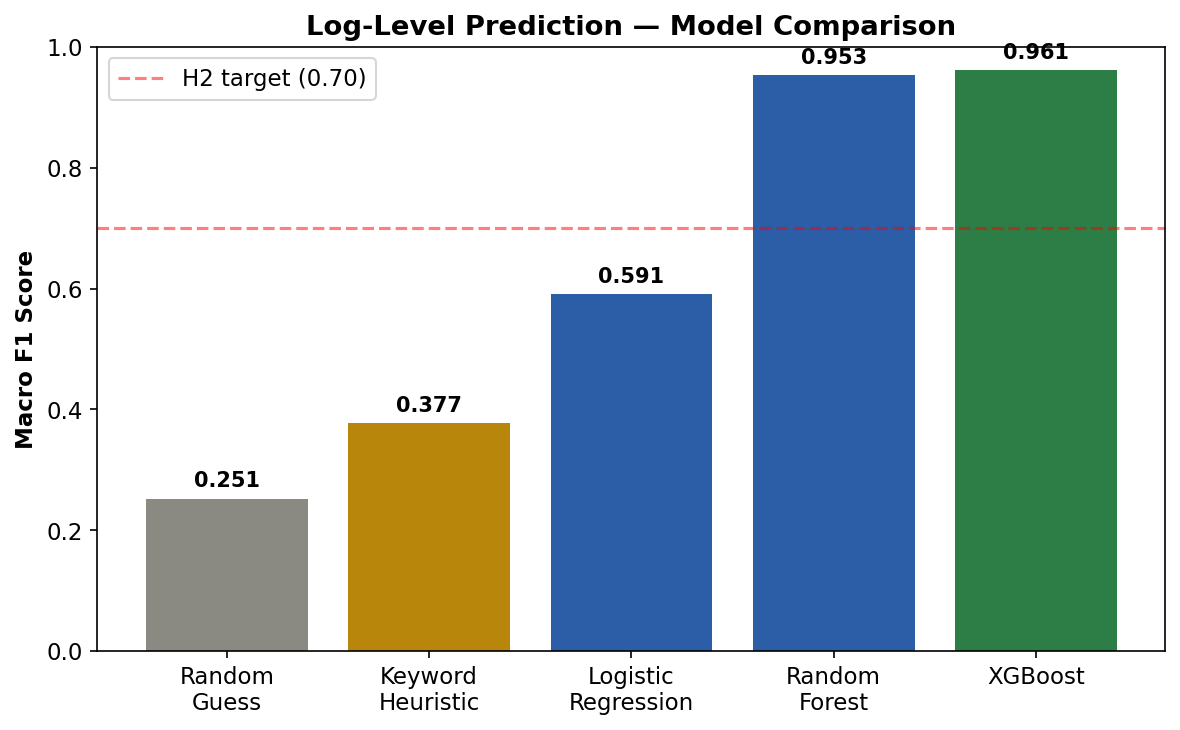

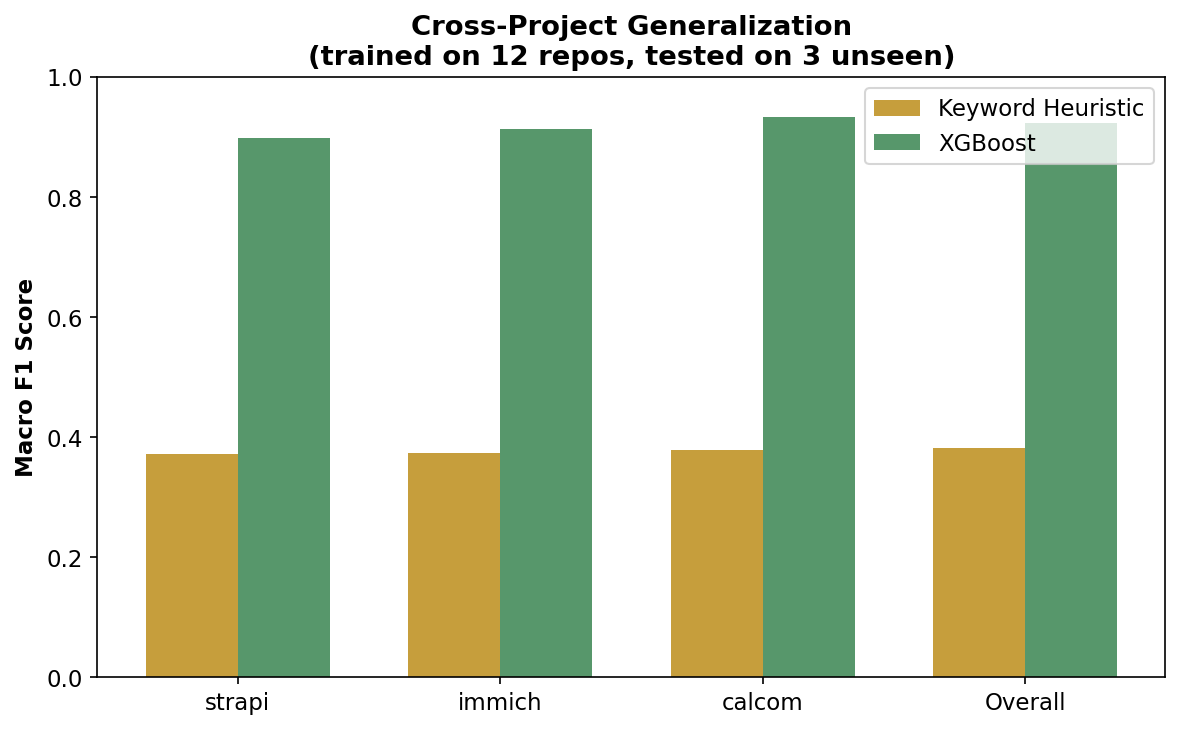

In [20]:
# --- Figure 7: Model Comparison ---
fig, ax1 = plt.subplots(figsize=(8, 5))

model_names = ['Random\nGuess', 'Keyword\nHeuristic', 'Logistic\nRegression',
               'Random\nForest', 'XGBoost']

macro_f1_scores = [
    f1_score(y, random_preds, average='macro'),
    f1_score(y, heuristic_encoded, average='macro'),
    np.mean(cv_results['Logistic Regression']['macro_f1']),
    np.mean(cv_results['Random Forest']['macro_f1']),
    np.mean(cv_results['XGBoost']['macro_f1']),
]

colors = ['#8A8A82', '#B8860B', '#2B5EA7', '#2B5EA7', '#2D7D46']
bars = ax1.bar(model_names, macro_f1_scores, color=colors)
ax1.set_ylabel('Macro F1 Score', fontweight='bold')
ax1.set_title('Log-Level Prediction — Model Comparison', fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='H2 target (0.70)')
ax1.legend()

for bar, val in zip(bars, macro_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig07_model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 10: Cross-Project Generalization ---
fig, ax2 = plt.subplots(figsize=(8, 5))

cp_names = test_repos + ['Overall']
cp_ml_scores = []
cp_heur_scores = []
for repo in test_repos:
    repo_mask = df.loc[test_mask, 'repo'] == repo
    repo_y = y_cp_test[repo_mask.values]
    repo_pred = cp_preds[repo_mask.values]
    repo_heur = heuristic_cp_encoded[repo_mask.values]
    cp_ml_scores.append(f1_score(repo_y, repo_pred, average='macro'))
    cp_heur_scores.append(f1_score(repo_y, repo_heur, average='macro'))

cp_ml_scores.append(f1_score(y_cp_test, cp_preds, average='macro'))
cp_heur_scores.append(f1_score(y_cp_test, heuristic_cp_encoded, average='macro'))

x = np.arange(len(cp_names))
w = 0.35
ax2.bar(x - w/2, cp_heur_scores, w, label='Keyword Heuristic', color='#B8860B', alpha=0.8)
ax2.bar(x + w/2, cp_ml_scores, w, label='XGBoost', color='#2D7D46', alpha=0.8)
ax2.set_ylabel('Macro F1 Score', fontweight='bold')
ax2.set_title('Cross-Project Generalization\n(trained on 12 repos, tested on 3 unseen)',
              fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cp_names)
ax2.legend()
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig10_cross_project.png'), dpi=300, bbox_inches='tight')
plt.show()

<cell_type>markdown</cell_type>## Summary
#
# Key results from log-level classification:
# - XGBoost best model; outperforms keyword heuristic baseline
# - Cross-project evaluation confirms generalization to unseen repos
# - Feature importance: structural features (in_catch, has_throw) + code context TF-IDF dominate
# - Error analysis reveals potential developer inconsistencies in level choice
# - H2 target (≥0.70 macro F1) — check results above
#
# **Figures saved**:
# - `fig07_model_comparison.png` — Baseline vs ML bars
# - `fig08_confusion_matrix.png` — Confusion matrix (counts + %)
# - `fig10_cross_project.png` — Cross-project per-repo bars
# - `fig11_feature_importance.png` — Top 25 feature importance
#
# **Next**: `03_ablation.ipynb` — Feature ablation study